In [3]:
import pandas as pd
train_df = pd.read_csv("../data/raw/UNSW_NB15_testing-set.csv")
print("Train shape:", train_df.shape)


Train shape: (175341, 45)


In [4]:
import numpy as np
print("Missing values :", train_df.isnull().sum().sum())
numeric_df = train_df.select_dtypes(include=np.number)
print("Infinite values:", np.isinf(numeric_df).sum().sum())

print("Label values:", train_df["label"].unique())

Missing values : 0
Infinite values: 0
Label values: [0 1]


In [5]:
invalid_rows = train_df[
    ((train_df["label"] == 0) &
     (train_df["attack_cat"] != "Normal"))
    |
    ((train_df["label"] == 1) &
     (train_df["attack_cat"] == "Normal"))
]

print("Inconsistent target rows:", len(invalid_rows))

Inconsistent target rows: 0


In [6]:
X = train_df.drop(
    columns=["id", "label", "attack_cat"]
)

y = train_df["label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (175341, 42)
Target: (175341,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (140272, 42)
Validation: (35069, 42)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "proto",
    "service",
    "state"
]

numerical_features = [
    column
    for column in X.columns
    if column not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 39
Categorical features: 3


In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original validation shape:", X_val.shape)
print("Processed validation shape:", X_val_processed.shape)

Original training shape: (140272, 42)
Processed training shape: (140272, 192)
Original validation shape: (35069, 42)
Processed validation shape: (35069, 192)


In [14]:
import numpy as np
from scipy import sparse

if sparse.issparse(X_train_processed):
    X_train_nn = X_train_processed.toarray().astype(np.float32)
    X_val_nn = X_val_processed.toarray().astype(np.float32)
else:
    X_train_nn = X_train_processed.astype(np.float32)
    X_val_nn = X_val_processed.astype(np.float32)

y_train_nn = y_train.to_numpy().astype(np.float32)
y_val_nn = y_val.to_numpy().astype(np.float32)

print("Training shape:", X_train_nn.shape)
print("Validation shape:", X_val_nn.shape)

Training shape: (140272, 192)
Validation shape: (35069, 192)


In [15]:
print(
    "Training data memory:",
    round(X_train_nn.nbytes / 1024**2, 2),
    "MB"
)

Training data memory: 102.74 MB


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

number_of_features = X_train_nn.shape[1]

model = keras.Sequential([
    layers.Input(shape=(number_of_features,)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(32, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

I0000 00:00:1786482640.420911  124476 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786482640.807605  124476 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786482643.527758  124476 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1786482646.344762  124476 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,841 (140.00 KB)

 Trainable params: 35,457 (138.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [18]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [19]:
history = model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    batch_size=256,
    callbacks=[
        early_stopping,
        reduce_learning_rate
    ],
    verbose=1
)

Epoch 1/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9235 - auc: 0.9752 - loss: 0.1688 - precision: 0.9242 - recall: 0.9670 - val_accuracy: 0.9396 - val_auc: 0.9867 - val_loss: 0.1266 - val_precision: 0.9341 - val_recall: 0.9804 - learning_rate: 0.0010
Epoch 2/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9371 - auc: 0.9853 - loss: 0.1297 - precision: 0.9300 - recall: 0.9815 - val_accuracy: 0.9412 - val_auc: 0.9878 - val_loss: 0.1214 - val_precision: 0.9453 - val_recall: 0.9697 - learning_rate: 0.0010
Epoch 3/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9382 - auc: 0.9862 - loss: 0.1254 - precision: 0.9324 - recall: 0.9802 - val_accuracy: 0.9422 - val_auc: 0.9884 - val_loss: 0.1201 - val_precision: 0.9497 - val_recall: 0.9662 - learning_rate: 0.0010
Epoch 4/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9391 - auc: 0.9868 - loss: 0.1231 - precision: 0.9351 - recall: 0.9784 - val_accuracy: 0.9425 - val_auc: 0.9885 - val_loss: 0.1176 -

In [24]:
# 2. Predict attack probabilities for validation data
y_probability = model.predict(
    X_val_nn,
    batch_size=256
).ravel()

# 3. Convert probability into Normal/Attack classes
y_pred = (y_probability >= 0.5).astype(int)

print("Probability shape:", y_probability.shape)
print("Prediction shape:", y_pred.shape)

print("First 10 probabilities:")
print(y_probability[:10])

print("First 10 predicted classes:")
print(y_pred[:10])

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Probability shape: (35069,)
Prediction shape: (35069,)
First 10 probabilities:
[0.9948628  0.99999946 0.9985501  0.9957486  0.99999285 0.9971823
 0.7130482  0.99999815 0.99999976 0.93754464]
First 10 predicted classes:
[1 1 1 1 1 1 1 1 1 1]


In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Confusion matrix:")
print(confusion_matrix(y_val_nn, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_val_nn,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val_nn, y_probability)
)

Confusion matrix:
[[10233   967]
 [  876 22993]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.92     11200
      Attack       0.96      0.96      0.96     23869

    accuracy                           0.95     35069
   macro avg       0.94      0.94      0.94     35069
weighted avg       0.95      0.95      0.95     35069

ROC-AUC: 0.9909481870537398


In [26]:
results = model.evaluate(
    X_val_nn,
    y_val_nn,
    verbose=0,
    return_dict=True
)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.9474
auc: 0.9907
loss: 0.1057
precision: 0.9596
recall: 0.9633


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Confusion matrix:")
print(confusion_matrix(y_val_nn, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_val_nn,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val_nn, y_probability)
)

Confusion matrix:
[[10233   967]
 [  876 22993]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.92     11200
      Attack       0.96      0.96      0.96     23869

    accuracy                           0.95     35069
   macro avg       0.94      0.94      0.94     35069
weighted avg       0.95      0.95      0.95     35069

ROC-AUC: 0.9909481870537398


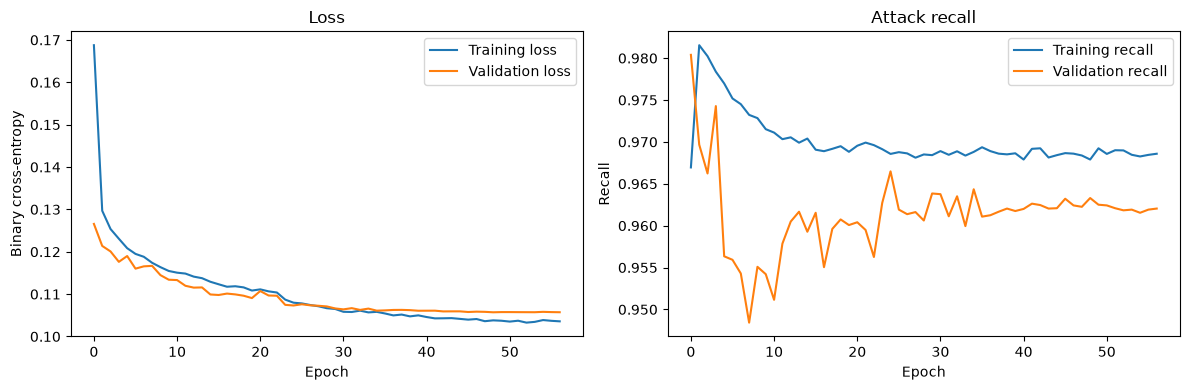

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["recall"], label="Training recall")
plt.plot(history.history["val_recall"], label="Validation recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Attack recall")
plt.legend()

plt.tight_layout()
plt.show()